<a href="https://colab.research.google.com/github/VikaSvyat/DI_Bootcamp/blob/main/Week17/PromptEng_W17_DailyChal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://octopus.developers.institute/courses/collection/124/course/728/section/1996/chapter/4560

Building an agent with LangGraph



 installing and importing the LangGraph SDK and LangChain support for the Gemini API

In [2]:
!pip install -qU "langgraph==1.1.5" "langchain-google-genai==4.1.2" "google-genai==1.66.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.2/732.2 kB 29.5 MB/s eta 0:00:00


In [4]:
import os
from google.colab import userdata
os.environ["GOOGLE_API_KEY"] =  userdata.get('GEMINI_API_KEY')

## Creating the Graph

In [5]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class OrderState(TypedDict):
    """State representing the customer's order conversation."""

    # The chat conversation. This preserves the conversation history
    # between nodes. The `add_messages` annotation indicates to LangGraph
    # that state is updated by appending returned messages, not replacing
    # them.
    messages: Annotated[list, add_messages]

    # The customer's in-progress order.
    order: list[str]

    # Flag indicating that the order is placed and completed.
    finished: bool
# The system instruction defines how the chatbot is expected to behave and includes
# rules for when to call different functions, as well as rules for the conversation, such
# as tone and what is permitted for discussion.
BARISTABOT_SYSINT = (
    "system",  # 'system' indicates the message is a system instruction.
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!",
)

# This is the message with which the system opens the conversation.
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

In [6]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

In [8]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = model.invoke(messages)
ai_msg

AIMessage(content="J'adore la programmation.", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e35f4-bb9a-7ce3-9d02-4d5bea5e0b8f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 7, 'total_tokens': 28, 'input_token_details': {'cache_read': 0}})

the following program defines a chatbot node that will execute a single turn in a chat conversation using the instructions supplied

In [9]:
from langgraph.graph import StateGraph, START, END
# from langchain_google_genai import ChatGoogleGenerativeAI

# Try using different models. The `pro` models perform the best, especially
# with tool-calling. The `flash` models are super fast, and are a good choice
# if you need to use the higher free-tier quota.
# Check out the features and quota differences here: https://ai.google.dev/pricing
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

def chatbot(state: OrderState) -> OrderState:
    """The chatbot itself. A simple wrapper around the model's own chat interface."""
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}


# Set up the initial graph based on our state definition.
graph_builder = StateGraph(OrderState)

# Add the chatbot function to the app graph as a node called "chatbot".
graph_builder.add_node("chatbot", chatbot)

# Define the chatbot node as the app entrypoint.
graph_builder.add_edge(START,"chatbot")

chat_graph = graph_builder.compile()

Visualise the graph

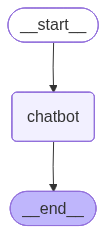

In [10]:
from IPython.display import Image

Image(chat_graph.get_graph().draw_mermaid_png())

## Running the graph

it will transition from start to chatbot, execute the chatbot node, and terminate.

In [11]:
user_msg = ("user", "I want a cappucino please.")
state=chat_graph.invoke({"messages":[user_msg]})

for msg in state["messages"]:
    print(f"{type(msg).__name__} : {msg.content}")

HumanMessage : I want a cappucino please.
AIMessage : Great choice! A Cappuccino coming right up.

Would you like anything else, or are you ready to confirm your order?


This second invocation takes the state from the first call and appends another user message to elicit another response from the chatbot.

In [13]:
user_msg = ("user", "Actually, make it iced.")
state["messages"].append(user_msg)
state=chat_graph.invoke({"messages":state["messages"]})
for msg in state["messages"]:
    print(f"{type(msg).__name__} : {msg.content}")

HumanMessage : I want a cappucino please.
AIMessage : Great choice! A Cappuccino coming right up.

Would you like anything else, or are you ready to confirm your order?
HumanMessage : Actually, make it iced.
AIMessage : Got it! One Iced Cappuccino coming up.

Is there anything else I can get for you today?
HumanMessage : Actually, make it iced.
AIMessage : I've already got that down as an Iced Cappuccino!

Is there anything else I can get for you, or any other modifications you'd like to make?


In [14]:
for msg in state["messages"]:
    print(f"{type(msg).__name__} : {msg.content}")

HumanMessage : I want a cappucino please.
AIMessage : Great choice! A Cappuccino coming right up.

Would you like anything else, or are you ready to confirm your order?
HumanMessage : Actually, make it iced.
AIMessage : Got it! One Iced Cappuccino coming up.

Is there anything else I can get for you today?
HumanMessage : Actually, make it iced.
AIMessage : I've already got that down as an Iced Cappuccino!

Is there anything else I can get for you, or any other modifications you'd like to make?


## Implementing the loop

Instead of repeatedly running the “graph” in a Python loop, you can use LangGraph to loop between nodes.

In [15]:
from langchain_core.messages.ai import AIMessage

def human_node(state: OrderState) -> OrderState:
  last_msg=state["messages"][-1]
  print(f"{type(last_msg).__name__} : {last_msg.content}")

  user_input = input("Your Answer : ")
  if user_input in {'q', 'quit', 'exit', 'goodbye'}:
    state["finished"] = True
  return state

In [16]:

# Set up the initial graph based on our state definition.
graph_builder = StateGraph(OrderState)

# Add the chatbot function to the app graph as a node called "chatbot".
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("human", human_node)

# Define the chatbot node as the app entrypoint.
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot","human")

Conditional edge functions take the state as input, and return a string representing the name of the node to which it will transition.

In [17]:
from typing import Annotated, Literal

def conditional_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
  if state.get("finished", False):
    return END
  else:
    return "chatbot"

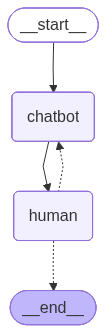

In [18]:
graph_builder.add_conditional_edges("human", conditional_exit_human_node)
chat_graph_3 = graph_builder.compile()
Image(chat_graph_3.get_graph().draw_mermaid_png())

There are two types of tools that this system will use. Stateless tools that can be run automatically, and stateful tools that modify the order. The “get current menu” tool is stateless, in that it does not make any changes to the live order, so it can be called automatically:

In [19]:
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage

@tool
def get_menu() -> str:
  """This tool provides the latest up-to-date menu."""
  return """
    # MENU:
    ## Coffee Drinks:
    - Espresso
    - Americano
    - Cold Brew

    ## Coffee Drinks with Milk:
    - Latte
    - Cappuccino
    - Cortado
    - Macchiato
    - Mocha
    - Flat White

    ## Tea Drinks:
    - English Breakfast Tea
    - Green Tea
    - Earl Grey

    ## Tea Drinks with Milk:
    - Chai Latte
    - Matcha Latte
    - London Fog

    ## Other Drinks:
    - Steamer
    - Hot Chocolate

 ## Modifiers:
    - Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
    - Espresso shots: Single, Double, Triple, Quadruple; default: Double
    - Caffeine: Decaf, Regular; default: Regular
    - Hot-Iced: Hot, Iced; Default: Hot
    - Sweeteners (option to add one or more): vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
    - Special requests: any reasonable modification that does not involve items not on the menu, for example: 'extra hot', 'one pump', 'half caff', 'extra foam', etc.

    - "dirty" means add a shot of espresso to a drink that doesn't usually have it, like "Dirty Chai Latte".
    - "Regular milk" is the same as 'whole milk'.
    - "Sweetened" means add some regular sugar, not a sweetener.

    > Soy milk has run out of stock today, so soy is not available.
  """

add the new tool to the graph. The get_menu tool is wrapped in a ToolNode that handles calling the tool and passing the response as a message through the graph. The tools are also bound to the llm object so that the underlying model knows they exist. As you now have a different llm object to invoke, you need to update the chatbot node so that it is aware of the tools.

In [23]:
auto_tools = [get_menu]
tools_by_name = {tool.name: tool for tool in auto_tools}

In [24]:
llm_with_tools = llm.bind_tools(auto_tools)

In [25]:
def tools_node(state: OrderState) -> dict:
  msgs = state.get("messages", [])

  last_msg = msgs[-1]
  result = []

  for tool_call in last_msg.additional_kwargs.get("tool_calls", []):
    tool_name = tool_call.function.name
    tool = tools_by_name[tool_name]
    args = tool_call.function.arguments
    tool_result = tool.invoke(args)

    result.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))

  return {"messages": result}

In [26]:
def conditional_tool_call(state: OrderState) -> Literal["tools", "human"]:
  if state["messages"][-1].additional_kwargs.get("tool_calls"):
    return "tools"
  else:
    return "human"

In [27]:
def chatbot_with_tools(state: OrderState) -> OrderState:
  defaults={"order":[],"finished":False}

  if state.get("messages"):
    new_output = llm_with_tools.invoke(state["messages"])
  else:
    new_output = AIMessage(content=WELCOME_MSG)

  return defaults | state | {"messages": [new_output]}

Handle orders

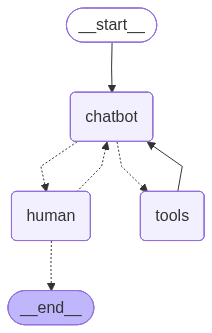

In [29]:
graph_builder = StateGraph(OrderState)

# Add the chatbot function to the app graph as a node called "chatbot".
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tools_node)

graph_builder.add_conditional_edges("human", conditional_exit_human_node)
graph_builder.add_conditional_edges("chatbot", conditional_tool_call)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")

chat_graph_5 = graph_builder.compile()

Image(chat_graph_5.get_graph().draw_mermaid_png())

## Test run

run the complete ordering system graph.

In [ ]:
user_msg = ("user", "I want a cappucino please.")
state=chat_graph_5.invoke({"messages":[user_msg]})

for msg in state["messages"]:
    print(f"{type(msg).__name__} : {msg.content}")